In [1]:
# Social_Network_Ads.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('Social_Network_Ads.csv')
df

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0
...,...,...,...,...,...
395,15691863,Female,46.0,41000.0,1
396,15706071,Male,51.0,23000.0,1
397,15654296,Female,50.0,20000.0,1
398,15755018,Male,36.0,33000.0,0


In [4]:
df.shape

(400, 5)

In [5]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

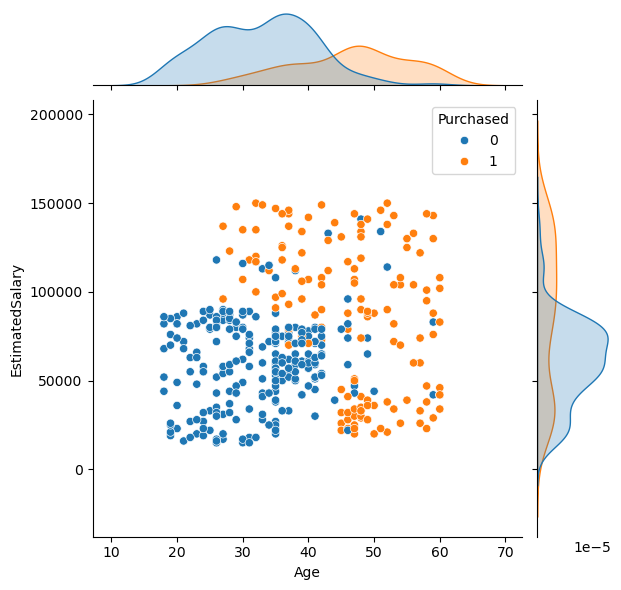

In [8]:
sns.jointplot(x = 'Age', y ='EstimatedSalary', data = df, hue ='Purchased')
# separate input and output
# check target distribution
# cross validation and feature scaling

In [9]:
x = df[['Age' , 'EstimatedSalary']]
y = df['Purchased']

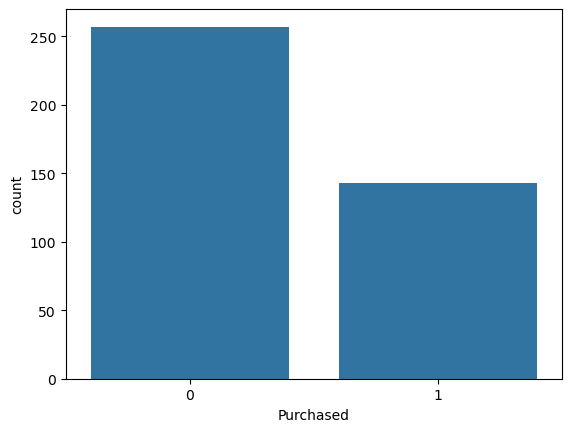

In [10]:
sns.countplot(x = y);

In [11]:
#check target distribution

In [52]:
x =df.drop('Purchased', axis =1)
y = df['Purchased']

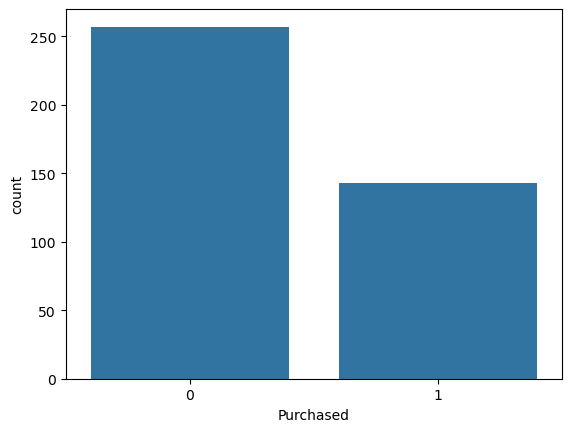

In [53]:
sns.countplot(x = y);

In [13]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y,
                                                    random_state=0)

In [14]:
# feature scaling

In [15]:
from sklearn.preprocessing import MinMaxScaler

sca = MinMaxScaler()

In [18]:
x_train_scaled = sca.fit_transform(x_train)
x_test_scaled = sca.transform(x_test)

In [19]:
# build the random forest model

In [20]:
from sklearn.ensemble import RandomForestClassifier

In [21]:
rf = RandomForestClassifier(random_state=0, n_estimators=50)

In [22]:
rf.fit(x_train_scaled, y_train)

,n_estimators,50
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [23]:
y_pred = rf.predict(x_test_scaled)

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, classification_report, accuracy_score

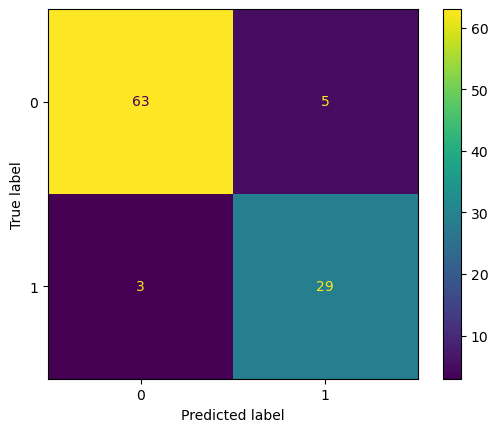

In [25]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred);

In [26]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        68
           1       0.85      0.91      0.88        32

    accuracy                           0.92       100
   macro avg       0.90      0.92      0.91       100
weighted avg       0.92      0.92      0.92       100



In [27]:
rf.feature_importances_

array([0.50052967, 0.49947033])

In [28]:
rf.estimators_;

In [29]:
# bagging of KNM

In [30]:
# check the accuracy using individual knn and compare with bagging of knn

In [32]:
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(x_train_scaled, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [36]:
y_pred = knn.predict(x_test_scaled)
accuracy_score(y_test, y_pred)

0.93

In [37]:
# bagging

In [38]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(KNeighborsClassifier(n_neighbors=5),
                        random_state= 0, n_estimators= 50)

In [39]:
bag.fit(x_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,n_estimators,50
,max_samples,1.0
,max_features,1.0
,bootstrap,True
,bootstrap_features,False
,oob_score,False
,warm_start,False
,n_jobs,None
,random_state,0
,verbose,0


In [40]:
y_pred = bag.predict(x_test_scaled)
accuracy_score(y_test, y_pred)

0.93

In [41]:
f = pd.read_csv('train.csv')
f.shape

(2000, 21)